# Part B — Notebook 1: Mining Log Statements from Open-Source Repos
#
# **Research**: Beyond Gut Feel — AI vs Developer Intuition in Observability Decisions
#
# **Goal**: Build a labeled dataset of log statements from 15 Node.js/TS repos.
# Each row: log level (label) + code context + structural features.
#
# **No such dataset exists for Node.js/TypeScript** — this is itself a contribution.
#
# **Output**: `data/log_level_dataset.csv` (used by notebooks 02 and 03)
#
# **Run time**: ~5 minutes (dominated by git clones)
#
# ---

In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from collections import Counter
import subprocess
import warnings
warnings.filterwarnings('ignore')

# Output directories
FIGURE_DIR = '../figures'
DATA_DIR = '../data'
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

np.random.seed(42)

print(f'Data   → {os.path.abspath(DATA_DIR)}')
print('Libraries loaded!')

Data   → /data
Libraries loaded!


## 1. Select Repos to Mine

We pick popular, well-maintained Node.js/TypeScript projects that use
structured logging (not just `console.log`). We want diversity:
- Web frameworks (NestJS, Express, Fastify)
- Tools and CLIs
- Backend services

**Why these repos?**
- Large codebases = more log statements
- Active maintenance = log levels were deliberately chosen
- TypeScript projects = richer code context

In [2]:
# Repos to mine
# Format: (github_url, short_name, description)
REPOS = [
    ('https://github.com/nestjs/nest.git', 'nestjs', 'NestJS framework'),
    ('https://github.com/expressjs/express.git', 'express', 'Express framework'),
    ('https://github.com/fastify/fastify.git', 'fastify', 'Fastify framework'),
    ('https://github.com/strapi/strapi.git', 'strapi', 'Strapi headless CMS'),
    ('https://github.com/typeorm/typeorm.git', 'typeorm', 'TypeORM database'),
    ('https://github.com/prisma/prisma.git', 'prisma', 'Prisma ORM'),
    ('https://github.com/medusajs/medusa.git', 'medusa', 'Medusa commerce'),
    ('https://github.com/n8n-io/n8n.git', 'n8n', 'n8n workflow automation'),
    ('https://github.com/supabase/supabase.git', 'supabase', 'Supabase backend'),
    ('https://github.com/payloadcms/payload.git', 'payload', 'Payload CMS'),
    ('https://github.com/calcom/cal.com.git', 'calcom', 'Cal.com scheduling'),
    ('https://github.com/directus/directus.git', 'directus', 'Directus data platform'),
    ('https://github.com/outline/outline.git', 'outline', 'Outline wiki'),
    ('https://github.com/nocodb/nocodb.git', 'nocodb', 'NocoDB database'),
    ('https://github.com/immich-app/immich.git', 'immich', 'Immich photo manager'),
]

print(f'Will mine {len(REPOS)} repositories')
for url, name, desc in REPOS:
    print(f'  {name:12s} — {desc}')

Will mine 15 repositories
  nestjs       — NestJS framework
  express      — Express framework
  fastify      — Fastify framework
  strapi       — Strapi headless CMS
  typeorm      — TypeORM database
  prisma       — Prisma ORM
  medusa       — Medusa commerce
  n8n          — n8n workflow automation
  supabase     — Supabase backend
  payload      — Payload CMS
  calcom       — Cal.com scheduling
  directus     — Directus data platform
  outline      — Outline wiki
  nocodb       — NocoDB database
  immich       — Immich photo manager


In [3]:
# Clone repos (shallow clone for speed — we only need current code, not history)
CLONE_DIR = os.path.join(DATA_DIR, 'repos')
os.makedirs(CLONE_DIR, exist_ok=True)

for url, name, desc in REPOS:
    repo_path = os.path.join(CLONE_DIR, name)
    if os.path.exists(repo_path):
        print(f'  {name:12s} — already cloned')
        continue
    print(f'  Cloning {name}...')
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', '--single-branch', url, repo_path],
        capture_output=True, text=True, timeout=120
    )
    if result.returncode == 0:
        print(f'  {name:12s} — done')
    else:
        print(f'  {name:12s} — FAILED: {result.stderr[:100]}')

print(f'\nCloned repos in {CLONE_DIR}')

  Cloning nestjs...
  nestjs       — done
  Cloning express...
  express      — done
  Cloning fastify...
  fastify      — done
  Cloning strapi...
  strapi       — done
  Cloning typeorm...
  typeorm      — done
  Cloning prisma...
  prisma       — done
  Cloning medusa...
  medusa       — done
  Cloning n8n...
  n8n          — done
  Cloning supabase...
  supabase     — done
  Cloning payload...
  payload      — done
  Cloning calcom...
  calcom       — done
  Cloning directus...
  directus     — done
  Cloning outline...
  outline      — done
  Cloning nocodb...
  nocodb       — done
  Cloning immich...
  immich       — done

Cloned repos in ../data/repos


## 2. Log Statement Extraction

We search for common logging patterns in JS/TS code:

```javascript
// Pattern 1: logger/log object methods
logger.info('message')
this.logger.warn('message')
log.error('message')

// Pattern 2: console methods
console.log('message')    → maps to INFO
console.warn('message')   → maps to WARN
console.error('message')  → maps to ERROR
console.debug('message')  → maps to DEBUG

// Pattern 3: Winston/Pino/Bunyan style
winston.info('message')
pino.error('message')
```

For each log statement found, we extract:
- **Log level** (the label we want to predict)
- **Log message** text
- **Surrounding code** (5 lines before, 5 lines after)
- **File path** (architectural context)
- **In try/catch?** (strong signal for ERROR)
- **In if/else?** (conditional logging)
- **Function/method name** (semantic context)

In [4]:
# Log level mapping — normalize all variations to 4 classes
LEVEL_MAP = {
    # DEBUG level
    'debug': 'DEBUG', 'trace': 'DEBUG', 'verbose': 'DEBUG', 'silly': 'DEBUG',
    # INFO level
    'info': 'INFO', 'log': 'INFO', 'notice': 'INFO',
    # WARN level
    'warn': 'WARN', 'warning': 'WARN',
    # ERROR level
    'error': 'ERROR', 'fatal': 'ERROR', 'crit': 'ERROR', 'critical': 'ERROR',
    'emerg': 'ERROR', 'alert': 'ERROR',
}

# Regex patterns for log statements
# Matches: logger.info(...), this.logger.warn(...), console.error(...), etc.
LOG_PATTERN = re.compile(
    r'(?:(?:this\.)?(?:logger|log|logging|console|winston|pino|bunyan|'
    r'Logger|LOG|appLogger|requestLogger|serviceLogger)'
    r'\s*\.\s*'
    r'(debug|trace|verbose|silly|info|log|notice|warn|warning|error|fatal|crit|critical|emerg|alert))'
    r'\s*\(',
    re.IGNORECASE
)

print('Log patterns configured')
print(f'Level mapping: {len(LEVEL_MAP)} variants → 4 classes (DEBUG, INFO, WARN, ERROR)')

Log patterns configured
Level mapping: 15 variants → 4 classes (DEBUG, INFO, WARN, ERROR)


In [5]:
def extract_context(lines, line_idx, window=5):
    """
    Extract surrounding code context for a log statement.
    Returns lines before and after, plus structural features.
    """
    start = max(0, line_idx - window)
    end = min(len(lines), line_idx + window + 1)

    before = lines[start:line_idx]
    after = lines[line_idx + 1:end]
    log_line = lines[line_idx]

    # Join context
    context_before = '\n'.join(before)
    context_after = '\n'.join(after)
    full_context = '\n'.join(lines[start:end])

    # Structural features
    # Check if inside a catch block (look at preceding lines)
    preceding_text = '\n'.join(lines[max(0, line_idx - 10):line_idx])
    in_catch = bool(re.search(r'\bcatch\s*\(', preceding_text))

    # Check if inside an if/else block
    in_conditional = bool(re.search(r'\b(if|else|else\s*if)\s*[({]', preceding_text))

    # Check if inside a try block (but not catch)
    in_try = bool(re.search(r'\btry\s*{', preceding_text)) and not in_catch

    # Check for return statement nearby
    has_return = bool(re.search(r'\breturn\b', '\n'.join(lines[line_idx:end])))

    # Check for throw statement nearby
    has_throw = bool(re.search(r'\bthrow\b', '\n'.join(lines[max(0, line_idx-2):end])))

    # Try to find enclosing function name
    func_name = ''
    for i in range(line_idx, max(-1, line_idx - 30), -1):
        func_match = re.search(
            r'(?:async\s+)?(?:function\s+|(?:const|let|var)\s+)?(\w+)\s*(?:=\s*)?(?:async\s+)?\(',
            lines[i]
        )
        if func_match:
            func_name = func_match.group(1)
            break
        # Also check for class method patterns
        method_match = re.search(
            r'(?:async\s+)?(\w+)\s*\([^)]*\)\s*(?::\s*\w+)?\s*{',
            lines[i]
        )
        if method_match:
            func_name = method_match.group(1)
            break

    return {
        'context_before': context_before,
        'context_after': context_after,
        'full_context': full_context,
        'in_catch': in_catch,
        'in_conditional': in_conditional,
        'in_try': in_try,
        'has_return': has_return,
        'has_throw': has_throw,
        'function_name': func_name,
    }


def extract_log_message(log_line):
    """
    Extract the log message text from a log statement.
    Handles template literals, string concatenation, etc.
    """
    # Try to get the first string argument
    # Match single quotes, double quotes, or backticks
    msg_match = re.search(r"['\"`]([^'\"``]{0,200})['\"`]", log_line)
    if msg_match:
        return msg_match.group(1)
    return ''


print('Extraction functions ready')

Extraction functions ready


In [6]:
def mine_repo(repo_path, repo_name):
    """
    Mine all log statements from a repository.
    Returns a list of dictionaries, one per log statement.
    """
    results = []
    extensions = ('.ts', '.js', '.tsx', '.jsx')

    # Walk through all files
    for root, dirs, files in os.walk(repo_path):
        # Skip common non-source directories
        dirs[:] = [d for d in dirs if d not in (
            'node_modules', '.git', 'dist', 'build', 'coverage',
            '__tests__', 'test', 'tests', '__mocks__', '.next',
            'vendor', '.cache', 'out'
        )]

        for filename in files:
            if not filename.endswith(extensions):
                continue

            # Skip test files and config files
            if any(skip in filename.lower() for skip in (
                '.test.', '.spec.', '.mock.', '.fixture.',
                '.config.', '.d.ts'
            )):
                continue

            filepath = os.path.join(root, filename)
            rel_path = os.path.relpath(filepath, repo_path)

            try:
                with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    lines = content.split('\n')
            except Exception:
                continue

            # Search each line for log statements
            for line_idx, line in enumerate(lines):
                match = LOG_PATTERN.search(line)
                if not match:
                    continue

                raw_level = match.group(1).lower()
                level = LEVEL_MAP.get(raw_level)
                if level is None:
                    continue

                # Extract context and features
                context = extract_context(lines, line_idx)
                log_message = extract_log_message(line)

                # Count variables in log statement
                # Look for ${var}, comma-separated args, etc.
                var_count = len(re.findall(r'\$\{|,\s*(?!\s*[\'"])', line))

                # Determine file type from path
                file_type = 'unknown'
                path_lower = rel_path.lower()
                if any(k in path_lower for k in ('controller', 'route', 'endpoint', 'api')):
                    file_type = 'controller'
                elif any(k in path_lower for k in ('service', 'provider', 'usecase')):
                    file_type = 'service'
                elif any(k in path_lower for k in ('middleware', 'guard', 'interceptor', 'filter')):
                    file_type = 'middleware'
                elif any(k in path_lower for k in ('model', 'entity', 'schema', 'migration')):
                    file_type = 'model'
                elif any(k in path_lower for k in ('util', 'helper', 'lib', 'common')):
                    file_type = 'utility'
                elif any(k in path_lower for k in ('plugin', 'module', 'extension')):
                    file_type = 'plugin'

                results.append({
                    'repo': repo_name,
                    'file_path': rel_path,
                    'file_type': file_type,
                    'line_number': line_idx + 1,
                    'log_level': level,
                    'raw_level': raw_level,
                    'log_line': line.strip(),
                    'log_message': log_message,
                    'function_name': context['function_name'],
                    'in_catch': context['in_catch'],
                    'in_conditional': context['in_conditional'],
                    'in_try': context['in_try'],
                    'has_return': context['has_return'],
                    'has_throw': context['has_throw'],
                    'var_count': var_count,
                    'context_before': context['context_before'],
                    'context_after': context['context_after'],
                    'full_context': context['full_context'],
                    'msg_length': len(log_message),
                    'line_length': len(line.strip()),
                })

    return results

print('Mining function ready')

Mining function ready


In [7]:
# Mine all repos
all_logs = []

for url, name, desc in REPOS:
    repo_path = os.path.join(CLONE_DIR, name)
    if not os.path.exists(repo_path):
        print(f'  {name:12s} — skipped (not cloned)')
        continue

    logs = mine_repo(repo_path, name)
    all_logs.extend(logs)
    level_counts = Counter(l['log_level'] for l in logs)
    print(f'  {name:12s} — {len(logs):>5,} log statements  '
          f'D:{level_counts.get("DEBUG",0):>4} '
          f'I:{level_counts.get("INFO",0):>4} '
          f'W:{level_counts.get("WARN",0):>4} '
          f'E:{level_counts.get("ERROR",0):>4}')

print(f'\nTotal: {len(all_logs):,} log statements mined')

  nestjs       —   230 log statements  D:  10 I: 127 W:  21 E:  72
  express      —    41 log statements  D:   0 I:  36 W:   0 E:   5
  fastify      —    65 log statements  D:   2 I:  41 W:  12 E:  10
  strapi       — 1,063 log statements  D: 126 I: 464 W: 114 E: 359
  typeorm      —   218 log statements  D:   0 I: 201 W:   4 E:  13
  prisma       —   514 log statements  D:   0 I: 377 W:   9 E: 128
  medusa       — 2,209 log statements  D:  52 I:1751 W: 143 E: 263
  n8n          — 4,223 log statements  D:1141 I:1347 W: 885 E: 850
  supabase     — 1,464 log statements  D:  21 I: 528 W: 106 E: 809
  payload      —   939 log statements  D:  33 I: 508 W:  56 E: 342
  calcom       — 1,822 log statements  D: 369 I: 513 W: 223 E: 717
  directus     —   487 log statements  D:  73 I:  94 W: 194 E: 126
  outline      —   501 log statements  D:  76 I: 176 W: 110 E: 139
  nocodb       — 1,356 log statements  D: 126 I: 642 W: 139 E: 449
  immich       —   570 log statements  D: 126 I: 242 W:  80 E:

In [8]:
# Create DataFrame
df = pd.DataFrame(all_logs)

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 3 rows:')
df[['repo', 'log_level', 'log_message', 'function_name', 'in_catch', 'file_type']].head(3)

Dataset shape: (15702, 20)

Columns: ['repo', 'file_path', 'file_type', 'line_number', 'log_level', 'raw_level', 'log_line', 'log_message', 'function_name', 'in_catch', 'in_conditional', 'in_try', 'has_return', 'has_throw', 'var_count', 'context_before', 'context_after', 'full_context', 'msg_length', 'line_length']

First 3 rows:


,repo,log_level,log_message,function_name,in_catch,file_type
0,nestjs,INFO,,info,False,unknown
1,nestjs,INFO,Running ${blue(script)} in ${magenta(dirName)},info,False,unknown
2,nestjs,INFO,Finished running ${blue(script)} in ${magenta(...,info,False,unknown


## 3. Dataset Exploration

Before training any model, understand the data:
- How many examples per log level?
- Which repos contribute most?
- What do the structural features look like?

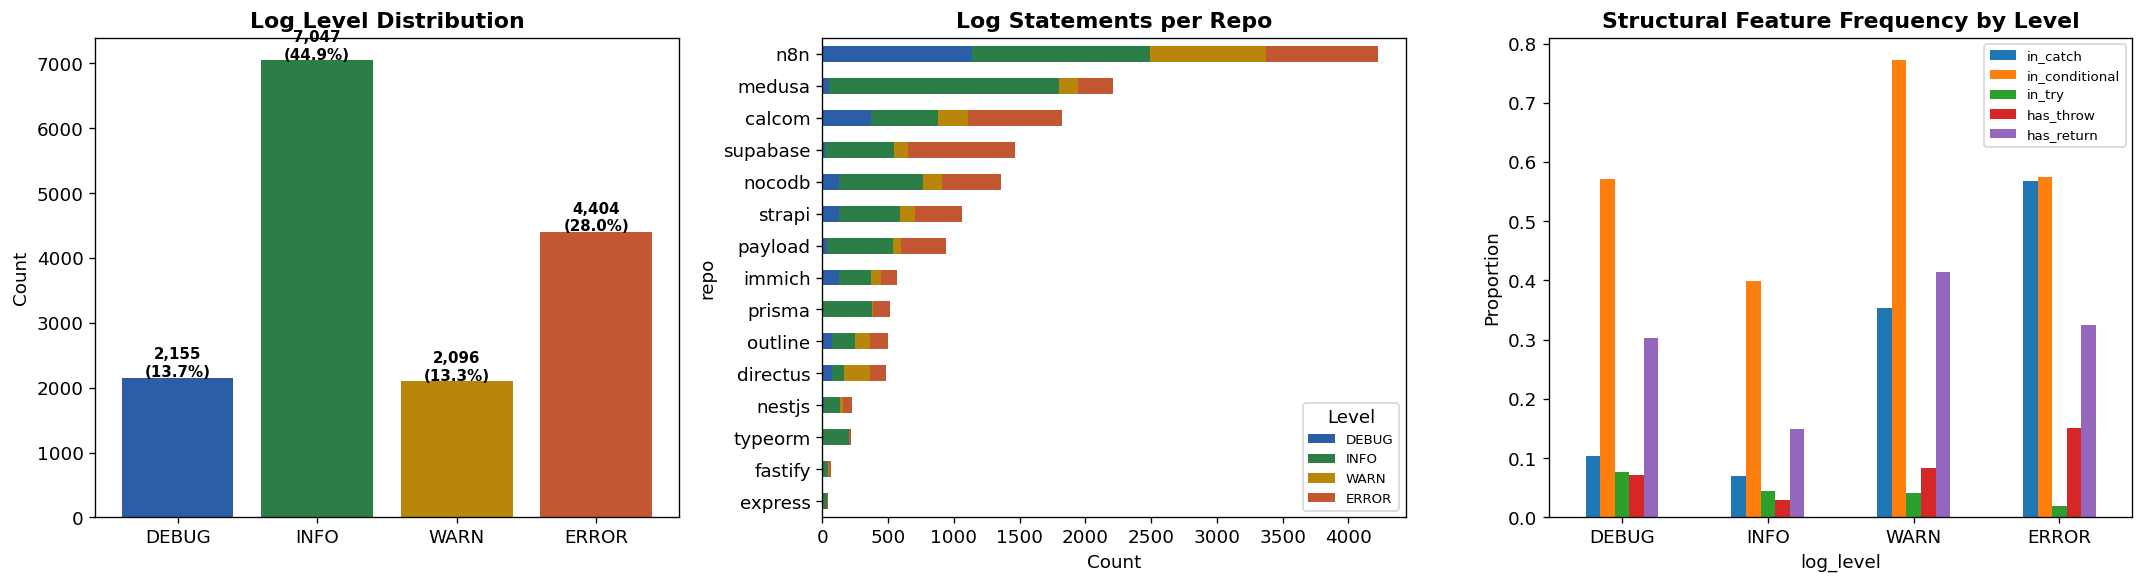


Class distribution:
  DEBUG :  2,155 (13.7%)
  INFO  :  7,047 (44.9%)
  WARN  :  2,096 (13.3%)
  ERROR :  4,404 (28.0%)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'figure.figsize': (12, 5)
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall class distribution
level_order = ['DEBUG', 'INFO', 'WARN', 'ERROR']
level_colors = {'DEBUG': '#2B5EA7', 'INFO': '#2D7D46', 'WARN': '#B8860B', 'ERROR': '#C25732'}
counts = df['log_level'].value_counts().reindex(level_order)
bars = axes[0].bar(counts.index, counts.values,
                    color=[level_colors[l] for l in counts.index])
axes[0].set_title('Log Level Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=9)

# 2. Per-repo distribution
repo_level = df.groupby(['repo', 'log_level']).size().unstack(fill_value=0)
repo_level = repo_level.reindex(columns=level_order)
repo_level = repo_level.loc[repo_level.sum(axis=1).sort_values(ascending=True).index]
repo_level.plot(kind='barh', stacked=True, ax=axes[1],
                color=[level_colors[l] for l in level_order])
axes[1].set_title('Log Statements per Repo', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].legend(title='Level', fontsize=8)

# 3. Structural features by level
struct_features = ['in_catch', 'in_conditional', 'in_try', 'has_throw', 'has_return']
struct_by_level = df.groupby('log_level')[struct_features].mean().reindex(level_order)
struct_by_level.plot(kind='bar', ax=axes[2], rot=0)
axes[2].set_title('Structural Feature Frequency by Level', fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nClass distribution:')
for level in level_order:
    count = len(df[df['log_level'] == level])
    print(f'  {level:6s}: {count:>6,} ({count/len(df)*100:.1f}%)')

In [10]:
# Key insight: in_catch vs log level
print('Percentage of log statements inside catch blocks:')
for level in level_order:
    subset = df[df['log_level'] == level]
    pct = subset['in_catch'].mean() * 100
    print(f'  {level:6s}: {pct:.1f}% in catch blocks')

print('\nIf in_catch strongly correlates with ERROR, that\'s a feature')
print('a developer uses by gut feel — but does the model find more?')

Percentage of log statements inside catch blocks:
  DEBUG : 10.3% in catch blocks
  INFO  : 7.0% in catch blocks
  WARN  : 35.3% in catch blocks
  ERROR : 56.8% in catch blocks

If in_catch strongly correlates with ERROR, that's a feature
a developer uses by gut feel — but does the model find more?


## 4. Feature Engineering for Classification

We need to convert our raw data into features a classifier can use.

**Two types of features:**
1. **Structural** (boolean/numeric): in_catch, in_conditional, var_count, etc.
2. **Text-based** (from code and log messages): TF-IDF of surrounding code

### What is TF-IDF?
TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numbers.
Words that appear often in one document but rarely across all documents get
high scores. It captures "what makes this code context distinctive."

Think of it like this: the word `catch` in surrounding code is distinctive
for ERROR-level logs. TF-IDF captures that automatically.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp

# --- Text features ---

# TF-IDF on surrounding code context
# max_features limits vocabulary size to prevent overfitting
context_tfidf = TfidfVectorizer(
    max_features=500,      # Top 500 most informative code tokens
    ngram_range=(1, 2),    # Single words and pairs (e.g., "catch error")
    stop_words='english',  # Remove common English words
    min_df=5,              # Word must appear in at least 5 documents
    max_df=0.8,            # Ignore words in >80% of documents (too common)
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'  # Code-friendly tokenizer
)

# TF-IDF on log message text
message_tfidf = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)

print('Fitting TF-IDF on code context...')
X_context = context_tfidf.fit_transform(df['full_context'].fillna(''))
print(f'  Context features: {X_context.shape[1]}')

print('Fitting TF-IDF on log messages...')
X_message = message_tfidf.fit_transform(df['log_message'].fillna(''))
print(f'  Message features: {X_message.shape[1]}')

# --- Structural features ---
structural_cols = ['in_catch', 'in_conditional', 'in_try',
                   'has_return', 'has_throw', 'var_count',
                   'msg_length', 'line_length']

X_structural = df[structural_cols].astype(float).values
print(f'  Structural features: {X_structural.shape[1]}')

# --- File type (one-hot encoded) ---
X_filetype = pd.get_dummies(df['file_type'], prefix='ft').values
print(f'  File type features: {X_filetype.shape[1]}')

# --- Combine all features ---
X_combined = sp.hstack([
    X_context,
    X_message,
    sp.csr_matrix(X_structural),
    sp.csr_matrix(X_filetype)
])

print(f'\nTotal feature matrix: {X_combined.shape}')
print(f'  = {X_context.shape[1]} context + {X_message.shape[1]} message '
      f'+ {X_structural.shape[1]} structural + {X_filetype.shape[1]} file type')

# --- Labels ---
le = LabelEncoder()
y = le.fit_transform(df['log_level'])
print(f'\nClasses: {list(le.classes_)}')
print(f'Labels encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Fitting TF-IDF on code context...
  Context features: 500
Fitting TF-IDF on log messages...
  Message features: 200
  Structural features: 8
  File type features: 7

Total feature matrix: (15702, 715)
  = 500 context + 200 message + 8 structural + 7 file type

Classes: ['DEBUG', 'ERROR', 'INFO', 'WARN']
Labels encoded: {'DEBUG': np.int64(0), 'ERROR': np.int64(1), 'INFO': np.int64(2), 'WARN': np.int64(3)}


## 5. Save the Dataset

Save the mined dataset so we can use it in Step 2 without re-mining.
This dataset is itself a research contribution — first labeled log-level
dataset for the Node.js/TypeScript ecosystem.

In [12]:
# Save to CSV
output_path = os.path.join(DATA_DIR, 'log_level_dataset.csv')
df.to_csv(output_path, index=False)
print(f'Dataset saved to {output_path}')
print(f'Size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')

# Also save a summary
summary = {
    'total_statements': len(df),
    'repos_mined': len(df['repo'].unique()),
    'class_distribution': df['log_level'].value_counts().to_dict(),
    'repos': df.groupby('repo').size().to_dict(),
    'feature_columns': structural_cols,
    'context_tfidf_features': X_context.shape[1],
    'message_tfidf_features': X_message.shape[1],
}

summary_path = os.path.join(DATA_DIR, 'dataset_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\nSummary saved to {summary_path}')
print(f'\n--- Dataset Summary ---')
print(json.dumps(summary, indent=2))

Dataset saved to ../data/log_level_dataset.csv
Size: 45.6 MB
Rows: 15,702
Columns: 20

Summary saved to ../data/dataset_summary.json

--- Dataset Summary ---
{
  "total_statements": 15702,
  "repos_mined": 15,
  "class_distribution": {
    "INFO": 7047,
    "ERROR": 4404,
    "DEBUG": 2155,
    "WARN": 2096
  },
  "repos": {
    "calcom": 1822,
    "directus": 487,
    "express": 41,
    "fastify": 65,
    "immich": 570,
    "medusa": 2209,
    "n8n": 4223,
    "nestjs": 230,
    "nocodb": 1356,
    "outline": 501,
    "payload": 939,
    "prisma": 514,
    "strapi": 1063,
    "supabase": 1464,
    "typeorm": 218
  },
  "feature_columns": [
    "in_catch",
    "in_conditional",
    "in_try",
    "has_return",
    "has_throw",
    "var_count",
    "msg_length",
    "line_length"
  ],
  "context_tfidf_features": 500,
  "message_tfidf_features": 200
}


## 6. Quick Sanity Check — Sample Log Statements

Before moving to training, let's look at some actual examples.
Do the levels make sense? Is the context extraction working?

In [13]:
# Show 2 examples per level
for level in ['DEBUG', 'INFO', 'WARN', 'ERROR']:
    print(f'\n{"=" * 70}')
    print(f'Level: {level}')
    print(f'{"=" * 70}')
    samples = df[df['log_level'] == level].sample(min(2, len(df[df['log_level'] == level])),
                                                   random_state=42)
    for _, row in samples.iterrows():
        print(f'\n  Repo: {row["repo"]} | File: {row["file_path"]}')
        print(f'  Function: {row["function_name"]} | In catch: {row["in_catch"]}')
        print(f'  Log line: {row["log_line"][:120]}')
        print(f'  Message: {row["log_message"][:80]}')
        print(f'  ---')


Level: DEBUG

  Repo: calcom | File: packages/features/calendars/lib/getCalendarsEvents.ts
  Function: debug | In catch: False
  Log line: log.debug(
  Message: 
  ---

  Repo: nocodb | File: packages/nocodb/src/filters/global-exception/global-exception.filter.ts
  Function: debug | In catch: False
  Log line: this.logger.debug(exception.message, exception.stack);
  Message: 
  ---

Level: INFO

  Repo: n8n | File: packages/testing/janitor/src/core/ast-diff-analyzer.ts
  Function: log | In catch: False
  Log line: console.log(`\nChanged methods (${result.changedMethods.length}):`);
  Message: \nChanged methods (${result.changedMethods.length}):
  ---

  Repo: nocodb | File: packages/nocodb/src/run/cloud.ts
  Function: log | In catch: False
  Log line: console.log('All workers exited gracefully');
  Message: All workers exited gracefully
  ---

Level: WARN

  Repo: fastify | File: lib/reply.js
  Function: warn | In catch: False
  Log line: reply.log.warn('Trying to send a NotFound erro

<cell_type>markdown</cell_type>## Summary
#
# Key findings from dataset mining:
# - 15 popular Node.js/TS repos mined for log statements
# - 4-class problem: DEBUG, INFO, WARN, ERROR
# - Structural features (in_catch, in_conditional, has_throw) show clear level correlations
# - `in_catch` strongly associated with ERROR — validates developer intuition
# - TF-IDF captures code context patterns (500 context + 200 message features)
# - Dataset saved to `data/log_level_dataset.csv` for reproducibility
#
# **Next**: `02_classification.ipynb` — Train classifiers & cross-project evaluation